In [1]:
datasets = [
    "mnist_red30_incremental",
    "mnist_red30_sml",
    "fashion_mnist_red50_incremental",
    "fashion_mnist_red50_sml"
]
root = "/Users/federicogiannini/Library/CloudStorage/OneDrive-PolitecnicodiMilano/SML_CL"
nconfs = 10
save = True
suffixes = []

In [2]:
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
def plot_kappa(perf, dataset):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,5))
    for m in perf:
        ax.plot(perf[m], label=m, linestyle="-")
        ax.scatter(x=np.arange(0,len(perf[m])), y=perf[m], s=15)
    ax.set_xticks(np.arange(0,len(perf[m])))
    ax.set_xticklabels([f"c_{i}" for i in range(0,len(perf[m]))])
    ax.legend(loc="best")
    ax.set_title(dataset)
    ax.set_xlabel("Concepts", loc="right")
    ax.set_ylabel("Cohen's Kappa", loc="top")
    plt.tight_layout()
    plt.grid()
    display(fig)
    if save:
        plt.savefig(os.path.join(root, "performance", f"{dataset}_kappa_cl.png"), dpi=300)
    plt.close(fig)

mnist_red30_incremental


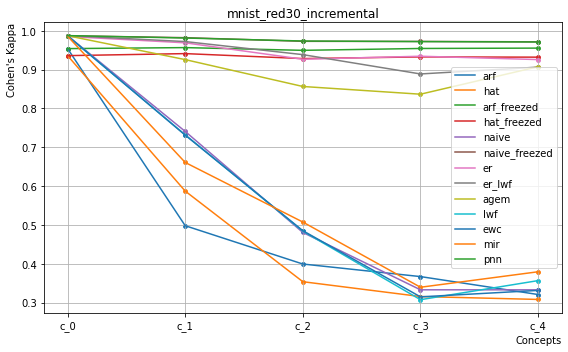

,model,average,a_metric,bwt
11,naive_freezed,0.971549,0.974538,0.000000
12,pnn,0.971120,0.974374,0.000000
2,arf_freezed,0.955356,0.954056,0.000000
3,er,0.925808,0.938013,-0.035860
7,hat_freezed,0.932070,0.932977,0.000000
4,er_lwf,0.906384,0.922314,-0.063452
0,agem,0.907435,0.886137,-0.125088
9,mir,0.379263,0.472225,-0.753749
8,lwf,0.356468,0.460937,-0.770455
10,naive,0.332752,0.460342,-0.771293


mnist_red30_sml


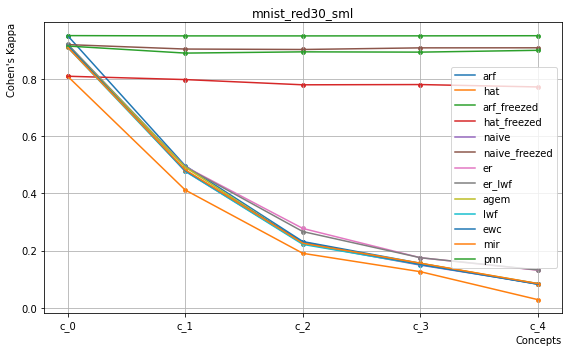

,model,average,a_metric,bwt
2,arf_freezed,0.950856,0.950548,0.000000
11,naive_freezed,0.908674,0.907587,0.000000
12,pnn,0.899908,0.896815,0.000000
7,hat_freezed,0.771865,0.781527,0.000000
3,er,0.131567,0.272593,-0.854778
4,er_lwf,0.132403,0.271309,-0.846845
1,arf,0.082383,0.244963,-1.058377
0,agem,0.084667,0.241464,-0.989659
9,mir,0.084803,0.240133,-1.007111
5,ewc,0.082701,0.239094,-1.007324


fashion_mnist_red50_incremental


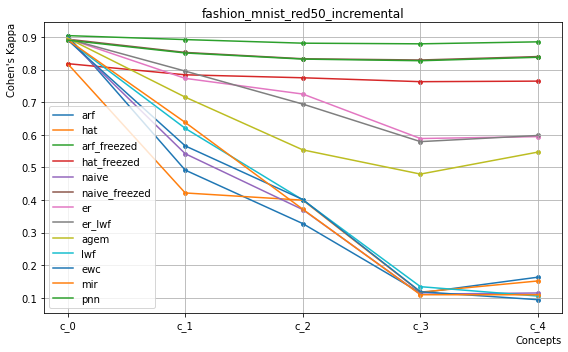

,model,average,a_metric,bwt
2,arf_freezed,0.88506,0.884820,0.00000
11,naive_freezed,0.83992,0.841020,0.00000
12,pnn,0.83772,0.839040,0.00000
7,hat_freezed,0.76456,0.772327,0.00000
3,er,0.59432,0.662767,-0.25104
4,er_lwf,0.59786,0.658147,-0.24753
0,agem,0.54700,0.576067,-0.36125
8,lwf,0.10520,0.292847,-0.82408
9,mir,0.10922,0.284353,-0.83469
5,ewc,0.09414,0.278120,-0.84375


fashion_mnist_red50_sml


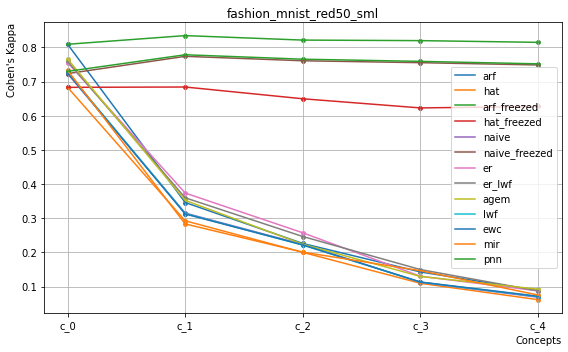

,model,average,a_metric,bwt
2,arf_freezed,0.814844,0.819759,0.000000
12,pnn,0.751917,0.758646,0.000000
11,naive_freezed,0.748670,0.754571,0.000000
7,hat_freezed,0.627237,0.641892,0.000000
4,er_lwf,0.087408,0.216978,-0.786480
3,er,0.087505,0.215587,-0.783506
1,arf,0.087988,0.212736,-0.910534
0,agem,0.092335,0.208180,-0.845241
9,mir,0.075291,0.190981,-0.825504
5,ewc,0.071831,0.188573,-0.845768


In [4]:
if type(nconfs)==int:
    nconfs = [nconfs]*len(datasets)
for dataset, nconf in zip(datasets, nconfs):
    print(dataset)
    cl_tables = []
    for conf in range(1, nconf+1):
        with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", "cl_table_sml_.pkl"), "rb") as f:
            table = pickle.load(f)
        with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", "cl_table_cl.pkl"), "rb") as f:
            table.update(pickle.load(f))
        for s in suffixes:
            with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", f"cl_table_cl_{s}.pkl"), "rb") as f:
                table.update(pickle.load(f))
        cl_tables.append(table)
    
    cl_table = {}
    for m in cl_tables[0]:
        cl_table[m] = {}
        for metric in ["accuracy", "kappa"]:
            cl_table[m][metric] = np.mean(np.array([table[m][metric] for table in cl_tables]), axis=0)
    
    cumulative = []
    for conf in range(nconf):
        cumulative.append({})
        for m in cl_tables[conf]:
            cumulative[-1][m] = []
            for i in range(len(cl_tables[conf][m]["kappa"])):
                cumulative[-1][m].append(np.mean(cl_tables[conf][m]["kappa"][i][:i+1]))
                
    cumulative_final = {}
    for m in cumulative[0]:
        cumulative_final[m] = np.mean(np.array([c[m] for c in cumulative]), axis=0)
    
    plot_kappa(cumulative_final, dataset)
    
    cl_metrics = []
    for conf, table in enumerate(cl_tables):
        cl_metrics.append({})
        for m in table:
            n = len(table[m]["kappa"])
            cl_metrics[-1][m] = {
                "average": np.mean(table[m]["kappa"][-1]),
                "a_metric": np.sum(
                    [
                        table[m]["kappa"][i][j]
                        for i in range(n)
                        for j in range(i+1)
                    ]
                )
                / (n * (n + 1) / 2),
                "bwt": np.sum(
                    [
                        (
                            table[m]["kappa"][i][j]
                            - table[m]["kappa"][j][j]
                        )
                        for i in range(1, n)
                        for j in range(i)
                    ]
                ) / (n * (n - 1) / 2),
                "conf": conf+1
            }  
    
    for i in range(len(cl_metrics)):
        cl_metrics[i] = pd.DataFrame(cl_metrics[i]).T.reset_index().rename(columns={'index': 'model'})
        
    cl_metrics = pd.concat(cl_metrics)
    if save:
        cl_metrics.to_excel(os.path.join(root, "performance", f"{dataset}_cl_metrics_all.xlsx"), index=False)
    cl_avg = cl_metrics.groupby("model").mean().drop(columns="conf").reset_index().sort_values("a_metric", ascending=False)
    if save:
        cl_avg.to_excel(os.path.join(root, "performance", f"{dataset}_cl_metrics.xlsx"), index=False)
    
    display(cl_avg)